## Generate Dataset

In [14]:
##create samples
import numpy as np
import pandas as pd

np.random.seed(42)

N_ROBOTS = 30
N_DAYS = 14
INTERVAL_MINUTES = 5

samples_per_day = 24 * 60 // INTERVAL_MINUTES
samples_per_robot = samples_per_day * N_DAYS

print("Samples per robot:", samples_per_robot)
print("Total samples:", samples_per_robot * N_ROBOTS)

Samples per robot: 4032
Total samples: 120960


In [15]:
## modes
MODES = ["PATROL", "ALERT", "CHARGING", "FAULT"]

mode_probabilities = {
    "PATROL": 0.65,
    "ALERT": 0.15,
    "CHARGING": 0.15,
    "FAULT": 0.05
}

In [16]:
## make the model to sustain for certain period
def generate_mode_sequence(n_samples):
    modes = []

    while len(modes) < n_samples:
        mode = np.random.choice(
            MODES,
            p=[
                mode_probabilities["PATROL"],
                mode_probabilities["ALERT"],
                mode_probabilities["CHARGING"],
                mode_probabilities["FAULT"]
            ]
        )

        if mode == "PATROL":
            duration = np.random.randint(12, 48)   # 1–4 hours

        elif mode == "ALERT":
            duration = np.random.randint(3, 12)    # 15–60 min

        elif mode == "CHARGING":
            duration = np.random.randint(12, 36)   # 1–3 hours

        else:  # FAULT
            duration = np.random.randint(3, 18)    # 15–90 min

        modes.extend([mode] * duration)

    return modes[:n_samples]

In [17]:
## modor generate sensor values
def generate_sensor_values(mode, t, battery_soc):
    
    if mode == "PATROL":
        accel_x = 0.4 * np.sin(2 * np.pi * t / 12) + np.random.normal(0, 0.15)
        accel_y = 0.3 * np.sin(2 * np.pi * t / 10) + np.random.normal(0, 0.15)
        accel_z = 9.81 + np.random.normal(0, 0.12)

        motor_current = (
            2.0
            + 0.4 * np.sin(2 * np.pi * t / 15)
            + np.random.normal(0, 0.15)
        )

        proximity = np.clip(
            3.0 + np.random.normal(0, 1.0),
            0.2,
            8.0
        )

        rssi = np.random.normal(-58, 5)

        battery_soc -= np.random.uniform(0.01, 0.04)

        task_success = np.random.choice(
            [1, 0],
            p=[0.95, 0.05]
        )
        
    elif mode == "ALERT":
        accel_x = (
                0.9 * np.sin(2 * np.pi * t / 7)+ np.random.normal(0, 0.3)
            )

        accel_y = (
            0.7 * np.sin(2 * np.pi * t / 6)
            + np.random.normal(0, 0.3)
        )

        accel_z = 9.81 + np.random.normal(0, 0.3)

        motor_current = (
            3.3
            + 0.8 * np.sin(2 * np.pi * t / 8)
            + np.random.normal(0, 0.3)
        )

        proximity = np.clip(
            1.5 + np.random.normal(0, 0.7),
            0.1,
            6.0
        )

        rssi = np.random.normal(-60, 6)

        battery_soc -= np.random.uniform(0.03, 0.07)

        task_success = np.random.choice(
            [1, 0],
            p=[0.9, 0.1]
        )
        
    elif mode == "CHARGING":

        accel_x = np.random.normal(0, 0.03)
        accel_y = np.random.normal(0, 0.03)
        accel_z = 9.81 + np.random.normal(0, 0.03)

        motor_current = np.random.normal(0.2, 0.05)

        proximity = np.clip(
            np.random.normal(0.4, 0.1),
            0.1,
            1.0
        )

        rssi = np.random.normal(-45, 3)

        battery_soc += np.random.uniform(0.08, 0.2)

        task_success = 1
        
    elif mode == "FAULT":

        accel_x = np.random.normal(0, 0.8)
        accel_y = np.random.normal(0, 0.8)
        accel_z = 9.81 + np.random.normal(0, 0.7)

        motor_current = (
            4.5
            + 1.2 * np.sin(2 * np.pi * t / 3)
            + np.random.normal(0, 0.7)
        )

        proximity = np.clip(
            np.random.normal(2.0, 1.5),
            0.1,
            8.0
        )

        rssi = np.random.normal(-72, 8)

        battery_soc -= np.random.uniform(0.05, 0.12)

        task_success = np.random.choice(
            [1, 0],
            p=[0.3, 0.7]
        )
        
    battery_soc = np.clip(battery_soc, 0, 100)

    return (
        accel_x,
        accel_y,
        accel_z,
        motor_current,
        proximity,
        rssi,
        battery_soc,
        task_success
    )

In [18]:
rows = []

start_time = pd.Timestamp("2026-08-10 00:00:00")

for robot_num in range(1, N_ROBOTS + 1):

    robot_id = f"R{robot_num:02d}"

    timestamps = pd.date_range(
        start=start_time,
        periods=samples_per_robot,
        freq="5min"
    )

    modes = generate_mode_sequence(samples_per_robot)

    battery_soc = np.random.uniform(60, 100)

    for t, (timestamp, mode) in enumerate(zip(timestamps, modes)):

        (
            accel_x,
            accel_y,
            accel_z,
            motor_current,
            proximity,
            rssi,
            battery_soc,
            task_success
        ) = generate_sensor_values(
            mode,
            t,
            battery_soc
        )

        rows.append({
            "timestamp": timestamp,
            "robot_id": robot_id,
            "mode": mode,
            "accel_x": accel_x,
            "accel_y": accel_y,
            "accel_z": accel_z,
            "motor_current": motor_current,
            "proximity": proximity,
            "rssi": rssi,
            "battery_soc": battery_soc,
            "task_success": task_success
        })

In [19]:
df = pd.DataFrame(rows)

df.head()

,timestamp,robot_id,mode,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success
0,2026-08-10 00:00:00,R01,PATROL,0.181560,-0.022685,9.765057,1.806318,2.234491,-55.888431,93.100778,0
1,2026-08-10 00:05:00,R01,PATROL,0.003813,-0.122254,9.707094,2.288695,4.781291,-61.387078,93.089032,1
2,2026-08-10 00:10:00,R01,PATROL,0.114086,0.233848,9.832063,2.383943,5.134641,-56.865756,93.065962,1
3,2026-08-10 00:15:00,R01,PATROL,0.412985,0.196385,9.728399,2.340912,2.719345,-61.019880,93.026576,1
4,2026-08-10 00:20:00,R01,PATROL,0.264022,0.340855,10.063573,2.323048,2.675605,-55.376955,93.016117,1


### Sanity check

In [20]:
df.shape

(120960, 11)

In [21]:
df["mode"].value_counts()

mode
PATROL      96458
CHARGING    17102
ALERT        5244
FAULT        2156
Name: count, dtype: int64

In [22]:
df["mode"].value_counts(normalize=True)

mode
PATROL      0.797437
CHARGING    0.141386
ALERT       0.043353
FAULT       0.017824
Name: proportion, dtype: float64

In [23]:
# Check missing values
df.isnull().sum()

timestamp        0
robot_id         0
mode             0
accel_x          0
accel_y          0
accel_z          0
motor_current    0
proximity        0
rssi             0
battery_soc      0
task_success     0
dtype: int64

In [24]:
# Basic statistics
df.describe()

,timestamp,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success
count,120960,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000
mean,2026-08-16 23:57:29.999999,0.000155,-0.001067,9.810299,1.847455,2.549354,-56.496667,70.264335,0.943312
min,2026-08-10 00:00:00,-2.513802,-2.482482,7.650570,-0.001142,0.100000,-95.513880,23.399879,0.000000
25%,2026-08-13 11:58:45,-0.231157,-0.174428,9.739428,1.621960,1.676326,-61.086181,57.903070,1.000000
50%,2026-08-16 23:57:30,0.000140,0.000214,9.809817,1.944115,2.695850,-57.121369,71.020018,1.000000
75%,2026-08-20 11:56:15,0.230678,0.173720,9.880330,2.273319,3.489544,-52.389033,83.487646,1.000000
max,2026-08-23 23:55:00,2.647071,2.687603,12.120806,7.449074,7.293276,-34.044172,100.000000,1.000000
std,NaN,0.338154,0.282058,0.155505,0.861987,1.309361,7.021399,16.646870,0.231247


In [25]:
df.groupby("mode")[
    ["accel_x", "accel_y", "accel_z",
     "motor_current", "proximity",
     "rssi", "battery_soc", "task_success"]
].mean().round(3)

,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success
mode,,,,,,,,
ALERT,0.000,-0.009,9.808,3.306,1.515,-59.939,69.794,0.902
CHARGING,0.000,0.000,9.810,0.200,0.399,-45.008,72.319,1.000
FAULT,0.002,-0.028,9.831,4.502,2.089,-71.900,69.552,0.289
PATROL,0.000,-0.000,9.810,2.001,2.997,-58.002,69.941,0.950


In [31]:
df["imu_magnitude"] = np.sqrt(
    df["accel_x"]**2 +
    df["accel_y"]**2 +
    df["accel_z"]**2
)

## PSD analysis

### time-series analysis

In [32]:
import matplotlib.pyplot as plt

r01 = df[df["robot_id"] == "R01"].copy()

start = r01["timestamp"].min()
end = start + pd.Timedelta(days=2)

r01_2days = r01[
    (r01["timestamp"] >= start) &
    (r01["timestamp"] < end)
]

r01_2days.shape

(576, 12)

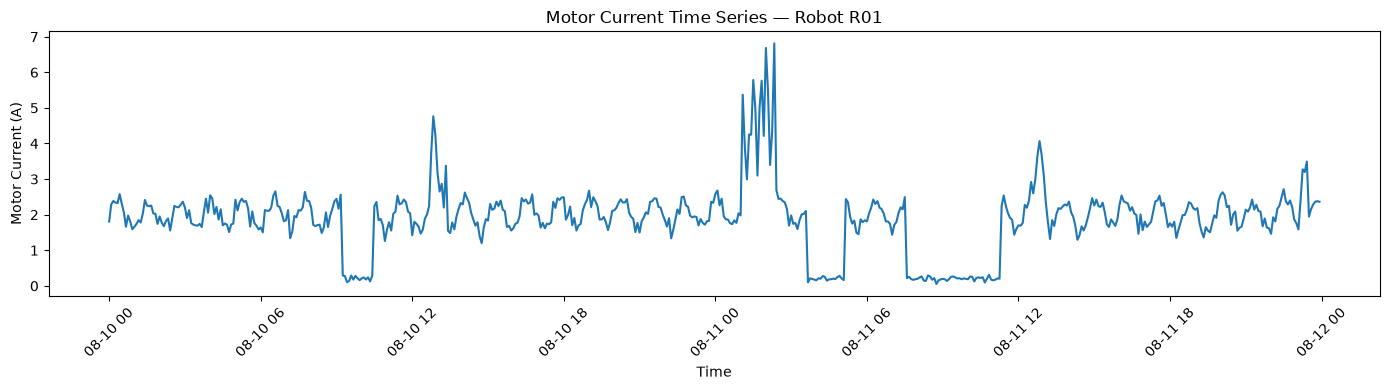

In [33]:
## plot motor current
plt.figure(figsize=(14, 4))

plt.plot(
    r01_2days["timestamp"],
    r01_2days["motor_current"]
)

plt.xlabel("Time")
plt.ylabel("Motor Current (A)")
plt.title("Motor Current Time Series — Robot R01")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

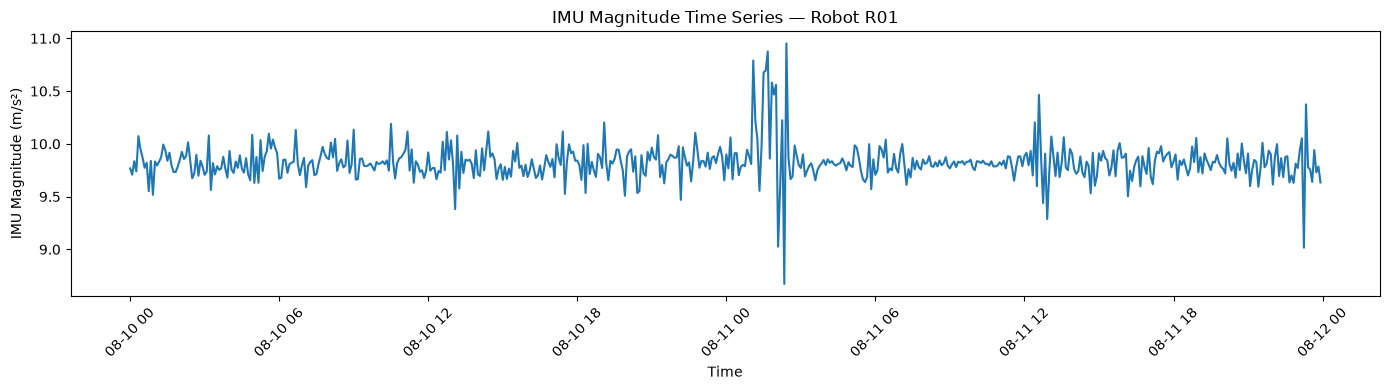

In [34]:
## IMU magnitude
plt.figure(figsize=(14, 4))

plt.plot(
    r01_2days["timestamp"],
    r01_2days["imu_magnitude"]
)

plt.xlabel("Time")
plt.ylabel("IMU Magnitude (m/s²)")
plt.title("IMU Magnitude Time Series — Robot R01")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

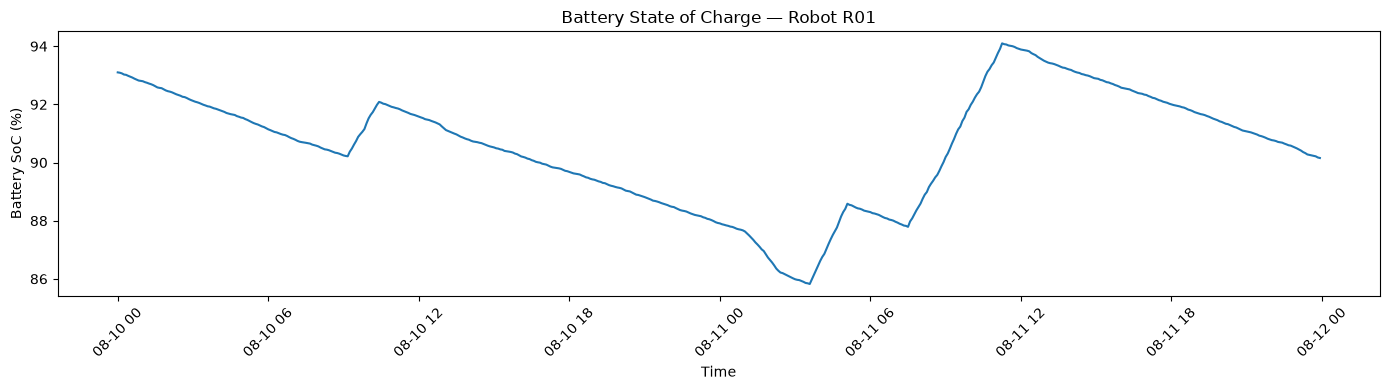

In [35]:
## battery
plt.figure(figsize=(14, 4))

plt.plot(
    r01_2days["timestamp"],
    r01_2days["battery_soc"]
)

plt.xlabel("Time")
plt.ylabel("Battery SoC (%)")
plt.title("Battery State of Charge — Robot R01")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
from scipy.signal import welch

In [42]:
sampling_interval_seconds = 5 * 60

fs = 1 / sampling_interval_seconds

print("Sampling frequency:", fs, "Hz")
print("Nyquist frequency:", fs / 2, "Hz")

Sampling frequency: 0.0033333333333333335 Hz
Nyquist frequency: 0.0016666666666666668 Hz


In [43]:
patrol_signal = r01[
    r01["mode"] == "PATROL"
]["motor_current"].values

In [44]:
freq_patrol, psd_patrol = welch(
    patrol_signal,
    fs=fs,
    nperseg=min(256, len(patrol_signal))
)

In [45]:
print(freq_patrol[:10])
print(psd_patrol[:10])

[0.00000000e+00 1.30208333e-05 2.60416667e-05 3.90625000e-05
 5.20833333e-05 6.51041667e-05 7.81250000e-05 9.11458333e-05
 1.04166667e-04 1.17187500e-04]
[ 6.1222623  25.10954627 21.87863481 22.05327942 17.99067925 28.28949607
 27.58786007 24.04125876 22.70424176 31.25735091]


In [46]:
fault_signal = r01[
    r01["mode"] == "FAULT"
]["motor_current"].values

freq_fault, psd_fault = welch(
    fault_signal,
    fs=fs,
    nperseg=min(256, len(fault_signal))
)

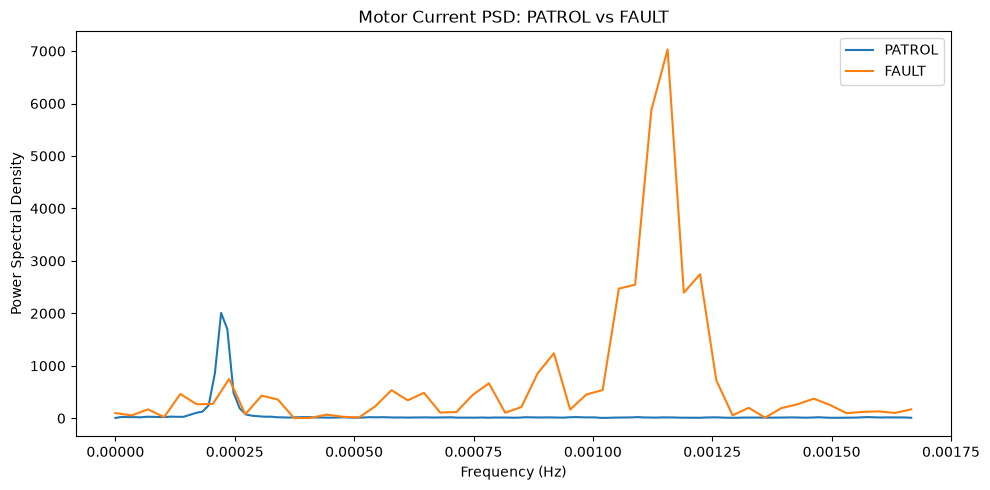

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    freq_patrol,
    psd_patrol,
    label="PATROL"
)

plt.plot(
    freq_fault,
    psd_fault,
    label="FAULT"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Motor Current PSD: PATROL vs FAULT")

plt.legend()
plt.tight_layout()
plt.show()

### continuous-segment PSD function

In [48]:
def get_continuous_segments(df, mode, signal_col, min_length=8):
    segments = []

    for robot_id, robot_df in df.groupby("robot_id"):
        robot_df = robot_df.sort_values("timestamp").copy()

        # Identify where mode changes
        group_id = (robot_df["mode"] != robot_df["mode"].shift()).cumsum()

        for _, segment in robot_df.groupby(group_id):
            if segment["mode"].iloc[0] == mode:
                signal = segment[signal_col].values

                if len(signal) >= min_length:
                    segments.append(signal)

    return segments

In [50]:
for mode in ["PATROL", "ALERT", "CHARGING", "FAULT"]:
    segments = get_continuous_segments(
        df,
        mode=mode,
        signal_col="motor_current",
        min_length=8
    )

    lengths = [len(seg) for seg in segments]

    print(
        mode,
        "| segments:", len(segments),
        "| mean length:", np.mean(lengths) if lengths else 0
    )

PATROL | segments: 1113 | mean length: 86.6460017969452
ALERT | segments: 347 | mean length: 11.023054755043228
CHARGING | segments: 623 | mean length: 27.443017656500803
FAULT | segments: 141 | mean length: 12.865248226950355


In [51]:
nperseg = 8

In [52]:
from scipy.signal import welch

fs = 1 / 300  # 5-minute sampling interval

def average_segment_psd(
    df,
    mode,
    signal_col,
    fs,
    nperseg=8
):
    segments = get_continuous_segments(
        df,
        mode=mode,
        signal_col=signal_col,
        min_length=nperseg
    )

    psds = []

    for segment in segments:
        freqs, psd = welch(
            segment,
            fs=fs,
            nperseg=nperseg
        )

        psds.append(psd)

    psds = np.array(psds)

    mean_psd = psds.mean(axis=0)

    return freqs, mean_psd, len(segments)

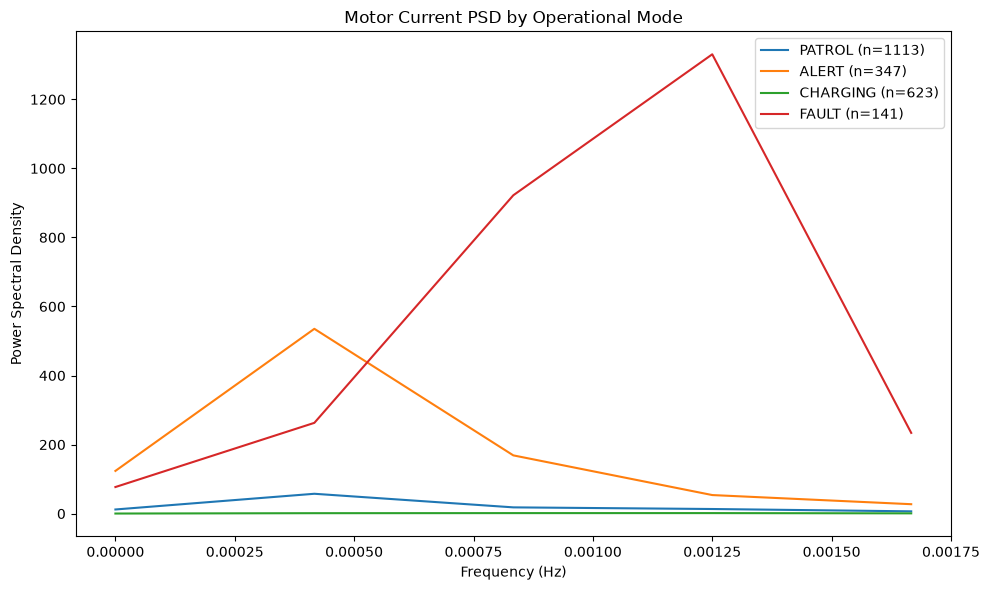

In [53]:
plt.figure(figsize=(10, 6))

for mode in ["PATROL", "ALERT", "CHARGING", "FAULT"]:

    freqs, mean_psd, n_segments = average_segment_psd(
        df=df,
        mode=mode,
        signal_col="motor_current",
        fs=fs,
        nperseg=8
    )

    plt.plot(
        freqs,
        mean_psd,
        label=f"{mode} (n={n_segments})"
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Motor Current PSD by Operational Mode")
plt.legend()

plt.tight_layout()
plt.show()

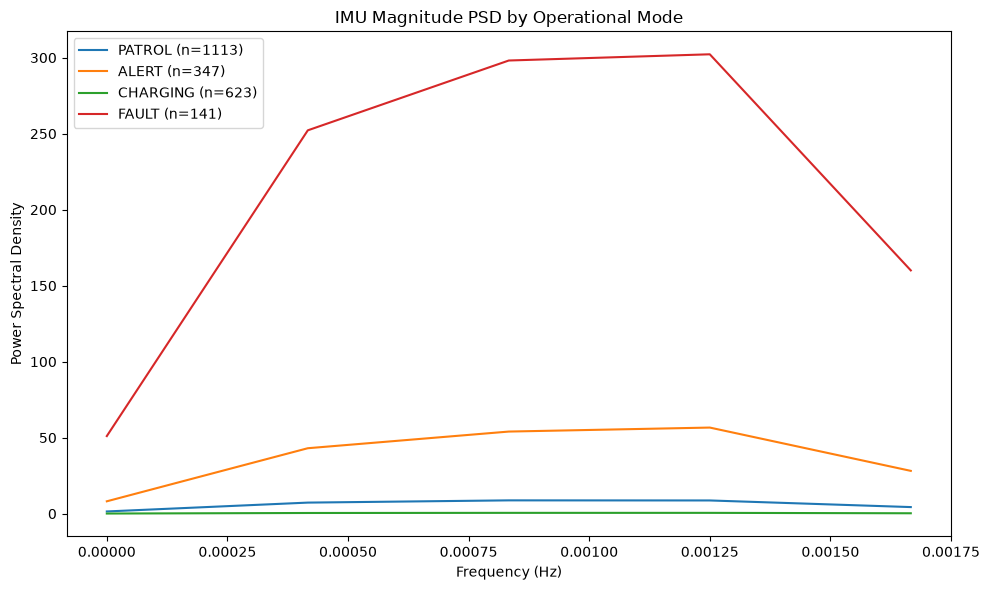

In [54]:
plt.figure(figsize=(10, 6))

for mode in ["PATROL", "ALERT", "CHARGING", "FAULT"]:

    freqs, mean_psd, n_segments = average_segment_psd(
        df=df,
        mode=mode,
        signal_col="imu_magnitude",
        fs=fs,
        nperseg=8
    )

    plt.plot(
        freqs,
        mean_psd,
        label=f"{mode} (n={n_segments})"
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("IMU Magnitude PSD by Operational Mode")
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
for mode in ["PATROL", "ALERT", "CHARGING", "FAULT"]:
    segments = get_continuous_segments(
        df,
        mode,
        "motor_current",
        min_length=8
    )

    print(
        mode,
        len(segments),
        np.mean([len(x) for x in segments])
    )

PATROL 1113 86.6460017969452
ALERT 347 11.023054755043228
CHARGING 623 27.443017656500803
FAULT 141 12.865248226950355


### PSD Observations

The Welch PSD analysis shows clear differences in frequency-domain
behavior across the simulated operational modes.

For motor current, PATROL exhibits relatively low spectral power,
whereas ALERT and especially FAULT show substantially greater power.
FAULT also contains stronger higher-frequency activity, reflecting the
more rapid and irregular motor-current fluctuations introduced during
synthetic data generation. CHARGING exhibits very little spectral
power because motor activity is minimal in this state.

A similar pattern is observed for IMU magnitude. CHARGING has the
lowest spectral activity, while FAULT shows the strongest broadband
power, consistent with increased simulated vibration and motion
irregularity.

Because these data are synthetic, these differences should be
interpreted as validation that the PSD pipeline can recover designed
mode-dependent temporal patterns rather than as empirical properties
of real Aido Rover telemetry.

## Band energy extraction

In [56]:
# Frequency bands adjusted to the observable range
frequency_bands = {
    "Low": (0.0, 0.0005),
    "Medium": (0.0005, 0.0010),
    "High": (0.0010, fs / 2)
}

frequency_bands

{'Low': (0.0, 0.0005),
 'Medium': (0.0005, 0.001),
 'High': (0.001, 0.0016666666666666668)}

### Frequency Band Definition

The original internship plan specifies low (0–0.5 Hz), medium
(0.5–2 Hz), and high (2–5 Hz) frequency bands. However, the synthetic
telemetry is sampled every 5 minutes, corresponding to a sampling
frequency of approximately 0.00333 Hz and a Nyquist frequency of
approximately 0.00167 Hz.

Therefore, the originally specified bands cannot be resolved from the
generated telemetry. For this analysis, the observable frequency range
is divided into three bands:

- Low: 0–0.0005 Hz
- Medium: 0.0005–0.0010 Hz
- High: 0.0010–0.00167 Hz

These adjusted bands are used only to demonstrate band-energy
extraction within the frequency range supported by the sampling rate.

In [62]:
def band_energy(freqs, psd, low, high):
    mask = (freqs >= low) & (freqs < high)

    df = freqs[1] - freqs[0]

    return np.sum(psd[mask]) * df

In [63]:
def band_energy(freqs, psd, low, high, include_high=False):
    if include_high:
        mask = (freqs >= low) & (freqs <= high)
    else:
        mask = (freqs >= low) & (freqs < high)

    dfreq = freqs[1] - freqs[0]

    return np.sum(psd[mask]) * dfreq

In [64]:
motor_band_results = {}

for mode in ["PATROL", "ALERT", "CHARGING", "FAULT"]:

    freqs, mean_psd, _ = average_segment_psd(
        df=df,
        mode=mode,
        signal_col="motor_current",
        fs=fs,
        nperseg=8
    )

    energies = {}

    for band_name, (low, high) in frequency_bands.items():

        energies[band_name] = band_energy(
            freqs,
            mean_psd,
            low,
            high,
            include_high=(band_name == "High")
        )

    motor_band_results[mode] = energies

motor_band_df = pd.DataFrame(motor_band_results).T
motor_band_df

,Low,Medium,High
PATROL,0.028960,0.007552,0.008329
ALERT,0.274585,0.070306,0.033780
CHARGING,0.000636,0.000618,0.000960
FAULT,0.141634,0.384203,0.651774


In [65]:
motor_relative_band_df = motor_band_df.div(
    motor_band_df.sum(axis=1),
    axis=0
)

motor_relative_band_df

,Low,Medium,High
PATROL,0.645831,0.168414,0.185755
ALERT,0.725129,0.185664,0.089206
CHARGING,0.287270,0.278988,0.433741
FAULT,0.120273,0.326256,0.553471


In [66]:
motor_relative_band_df.sum(axis=1)

PATROL      1.0
ALERT       1.0
CHARGING    1.0
FAULT       1.0
dtype: float64

### Motor Current Band-Energy Results

The band-energy analysis further distinguishes the simulated operational
modes in the frequency domain.

PATROL and ALERT are dominated by low-frequency motor-current activity,
with approximately 65% and 73% of their spectral energy in the low
frequency band, respectively. In contrast, FAULT shows a substantial
shift toward higher-frequency activity: approximately 33% of its energy
falls in the medium-frequency band and 55% in the high-frequency band.

This pattern is consistent with the Welch PSD results, where the
synthetic FAULT condition exhibited faster and more irregular
motor-current fluctuations than normal PATROL operation.

CHARGING has very low absolute spectral energy across all bands,
reflecting minimal motor activity. Its relative band proportions should
therefore be interpreted cautiously because normalization can make small
absolute fluctuations appear proportionally large.

In [67]:
imu_band_results = {}

for mode in ["PATROL", "ALERT", "CHARGING", "FAULT"]:

    freqs, mean_psd, _ = average_segment_psd(
        df=df,
        mode=mode,
        signal_col="imu_magnitude",
        fs=fs,
        nperseg=8
    )

    energies = {}

    for band_name, (low, high) in frequency_bands.items():

        energies[band_name] = band_energy(
            freqs,
            mean_psd,
            low,
            high,
            include_high=(band_name == "High")
        )

    imu_band_results[mode] = energies

imu_band_df = pd.DataFrame(imu_band_results).T

imu_relative_band_df = imu_band_df.div(
    imu_band_df.sum(axis=1),
    axis=0
)

imu_band_df

,Low,Medium,High
PATROL,0.003641,0.003648,0.005428
ALERT,0.021332,0.022508,0.035336
CHARGING,0.000225,0.000223,0.000333
FAULT,0.126359,0.124226,0.192617


In [68]:
imu_relative_band_df

,Low,Medium,High
PATROL,0.286293,0.286871,0.426836
ALERT,0.269425,0.284277,0.446298
CHARGING,0.287977,0.285366,0.426657
FAULT,0.285105,0.280292,0.434604


### IMU Band-Energy Results

Absolute IMU band energy differs substantially across operational
modes. FAULT exhibits the highest energy across all three frequency
bands, followed by ALERT and PATROL, while CHARGING shows minimal
spectral energy. This is consistent with the stronger simulated
acceleration variability during abnormal and high-activity states.

In contrast to motor current, the relative IMU band-energy
distributions are similar across modes. Approximately 27–29% of the
energy lies in the low and medium bands and 43–45% in the high band
for all four operational states.

This suggests that, in the synthetic dataset, operational modes affect
the overall magnitude of IMU spectral activity more strongly than its
relative frequency composition. Motor current, by comparison, shows
a clearer redistribution of spectral energy toward higher frequencies
during FAULT.

## HeatMap

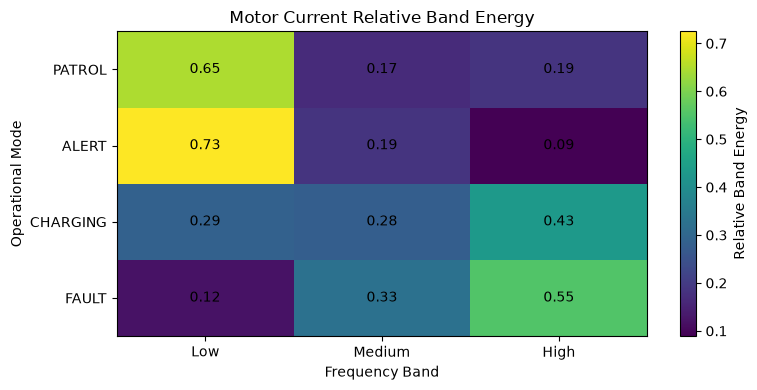

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.imshow(
    motor_relative_band_df.values,
    aspect="auto"
)

plt.xticks(
    range(len(motor_relative_band_df.columns)),
    motor_relative_band_df.columns
)

plt.yticks(
    range(len(motor_relative_band_df.index)),
    motor_relative_band_df.index
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("Motor Current Relative Band Energy")

plt.colorbar(label="Relative Band Energy")

# Add values inside cells
for i in range(len(motor_relative_band_df.index)):
    for j in range(len(motor_relative_band_df.columns)):
        plt.text(
            j,
            i,
            f"{motor_relative_band_df.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

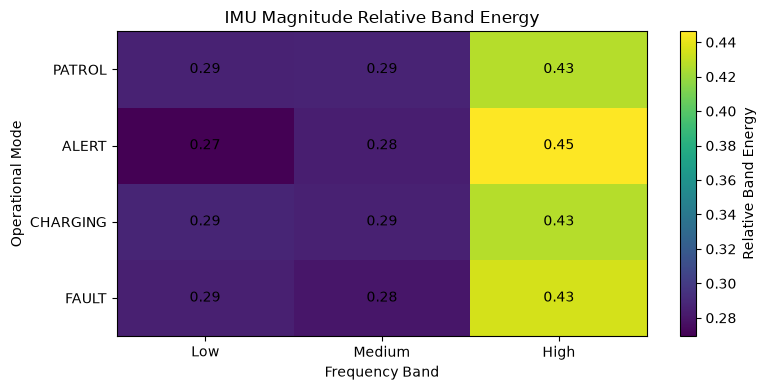

In [70]:
plt.figure(figsize=(8, 4))

plt.imshow(
    imu_relative_band_df.values,
    aspect="auto"
)

plt.xticks(
    range(len(imu_relative_band_df.columns)),
    imu_relative_band_df.columns
)

plt.yticks(
    range(len(imu_relative_band_df.index)),
    imu_relative_band_df.index
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("IMU Magnitude Relative Band Energy")

plt.colorbar(label="Relative Band Energy")

for i in range(len(imu_relative_band_df.index)):
    for j in range(len(imu_relative_band_df.columns)):
        plt.text(
            j,
            i,
            f"{imu_relative_band_df.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()